# AIML Final Portfolio Assessment 2026: Part III - Language Task
**Name**: Shoaib Siddiqui  
**WLVID**: 2407750

**Module**: 6CS012  

This notebook contains the workflow for Sentiment Analysis of Book Reviews using Simple RNN, LSTM, and Word2Vec Embeddings.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout

!pip install gensim
import gensim.downloader as api

nltk.download('stopwords')
nltk.download('wordnet')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 39.0 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

## 1. Text Preprocessing, Tokenization, and Sequence Padding
Load the dataset, clean the text, and tokenize it.


In [8]:
# Load dataset
df = pd.read_csv('/content/Book_review.csv') # Change path as needed in Colab
# Keep only text and rating
df = df[['reviewText', 'rating']].dropna()

# Text cleaning function
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# Apply cleaning (take a sample for faster processing if needed)
df['cleaned_text'] = df['reviewText'].apply(clean_text)

# Tokenization
vocab_size = 10000
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(df['cleaned_text'])
sequences = tokenizer.texts_to_sequences(df['cleaned_text'])

# Padding
sequence_lengths = [len(seq) for seq in sequences]
max_length = int(np.percentile(sequence_lengths, 95)) # 95th percentile padding
padded_sequences = pad_sequences(sequences, maxlen=max_length, padding='post')

# Target encoding (Ratings 1-5 -> 0-4)
labels = pd.get_dummies(df['rating']).values

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

X_train shape: (9600, 183), y_train shape: (9600, 5)


## 2. Simple RNN with Trainable Embedding


In [9]:
embedding_dim = 50

# Model 1: Simple RNN
model_rnn = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),
    SimpleRNN(64, return_sequences=False),
    Dropout(0.5),
    Dense(5, activation='softmax') # 5 classes
])

model_rnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_rnn.summary()

epochs = 5
batch_size = 64

history_rnn = model_rnn.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=epochs, batch_size=batch_size)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 12s 62ms/step - accuracy: 0.2405 - loss: 1.6007 - val_accuracy: 0.2562 - val_loss: 1.5917
Epoch 2/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.2669 - loss: 1.5798 - val_accuracy: 0.2608 - val_loss: 1.5896
Epoch 3/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.2845 - loss: 1.5704 - val_accuracy: 0.2542 - val_loss: 1.5898
Epoch 4/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.2769 - loss: 1.5707 - val_accuracy: 0.2463 - val_loss: 1.5903
Epoch 5/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.2766 - loss: 1.5607 - val_accuracy: 0.2433 - val_loss: 1.5880


## 3. LSTM with Trainable Embedding


In [10]:
# Model 2: LSTM
model_lstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),
    LSTM(64, return_sequences=False),
    Dropout(0.5),
    Dense(5, activation='softmax')
])

model_lstm.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_lstm.summary()

history_lstm = model_lstm.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=epochs, batch_size=batch_size)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 22s 127ms/step - accuracy: 0.2531 - loss: 1.5930 - val_accuracy: 0.2567 - val_loss: 1.5907
Epoch 2/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 22s 135ms/step - accuracy: 0.2594 - loss: 1.5894 - val_accuracy: 0.2475 - val_loss: 1.5893
Epoch 3/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 19s 129ms/step - accuracy: 0.2558 - loss: 1.5839 - val_accuracy: 0.2471 - val_loss: 1.5902
Epoch 4/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 20s 128ms/step - accuracy: 0.2583 - loss: 1.5746 - val_accuracy: 0.2458 - val_loss: 1.5857
Epoch 5/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 19s 129ms/step - accuracy: 0.2754 - loss: 1.5570 - val_accuracy: 0.2446 - val_loss: 1.5936


## 4. LSTM with pre-trained Word2Vec Embeddings
Using gensim to load Google News vectors (using glove-wiki-gigaword-50 as a fast alternative).


In [11]:
# Load pre-trained word vectors
print("Loading Word2Vec model...")
word2vec_model = api.load('glove-wiki-gigaword-50')

# Create embedding matrix
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in tokenizer.word_index.items():
    if i >= vocab_size:
        break
    if word in word2vec_model:
        embedding_matrix[i] = word2vec_model[word]

# Model 3: LSTM with Word2Vec
model_w2v = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, weights=[embedding_matrix], input_length=max_length, trainable=False),
    LSTM(64, return_sequences=False),
    Dropout(0.5),
    Dense(5, activation='softmax')
])

model_w2v.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_w2v.summary()

history_w2v = model_w2v.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=epochs, batch_size=batch_size)


Loading Word2Vec model...
[==================================================] 100.0% 66.0/66.0MB downloaded


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,000 (1.91 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 500,000 (1.91 MB)

Epoch 1/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 17s 99ms/step - accuracy: 0.2520 - loss: 1.5915 - val_accuracy: 0.2558 - val_loss: 1.5848
Epoch 2/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 20s 94ms/step - accuracy: 0.2586 - loss: 1.5824 - val_accuracy: 0.2575 - val_loss: 1.5836
Epoch 3/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 14s 95ms/step - accuracy: 0.2558 - loss: 1.5771 - val_accuracy: 0.2617 - val_loss: 1.5826
Epoch 4/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 22s 102ms/step - accuracy: 0.2570 - loss: 1.5773 - val_accuracy: 0.2500 - val_loss: 1.5819
Epoch 5/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 14s 95ms/step - accuracy: 0.2630 - loss: 1.5742 - val_accuracy: 0.2463 - val_loss: 1.5816


## 5. Evaluation and Comparison
Plotting Training vs Validation metrics and Confusion Matrix.


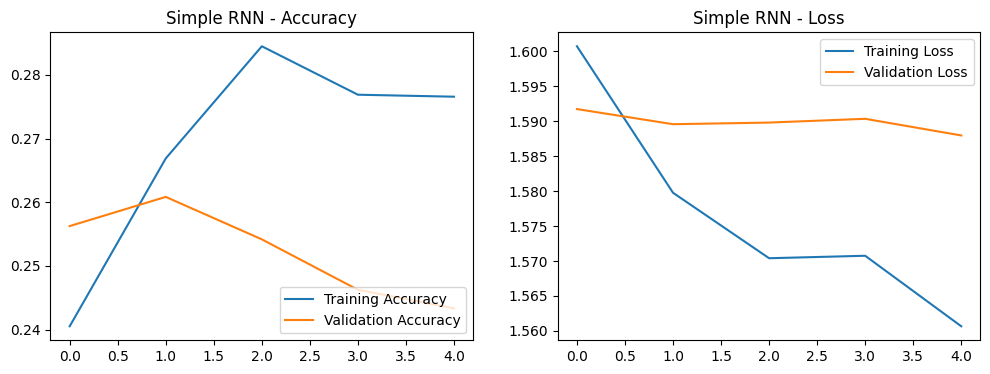

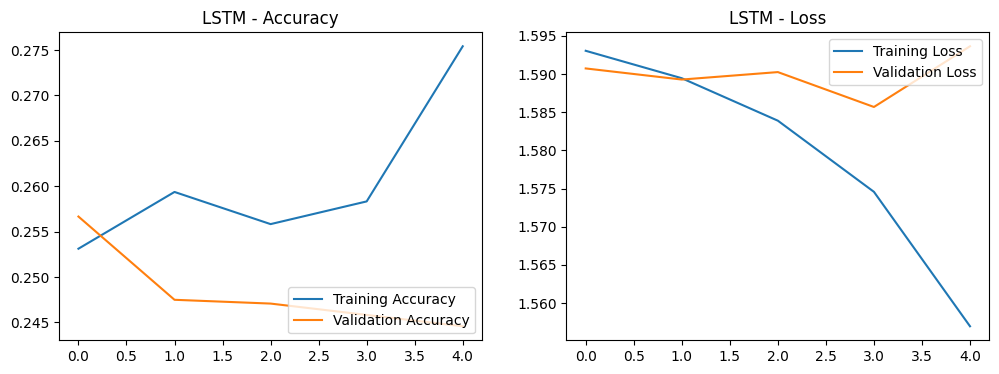

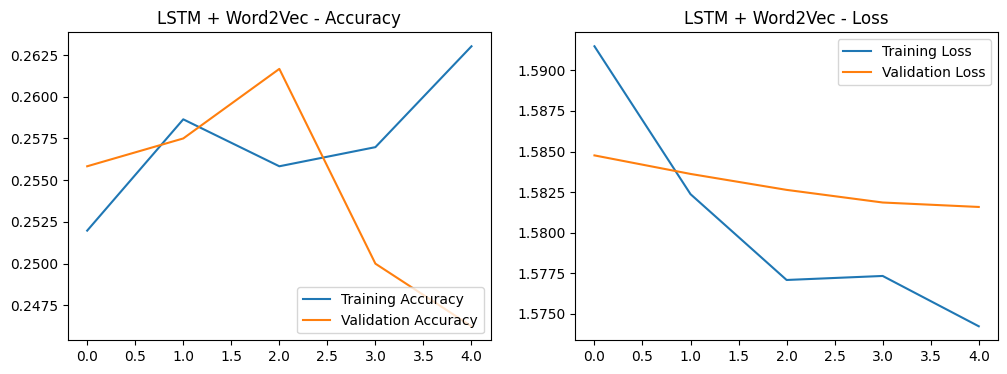

Evaluating LSTM + Word2Vec Model:
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step
Confusion Matrix


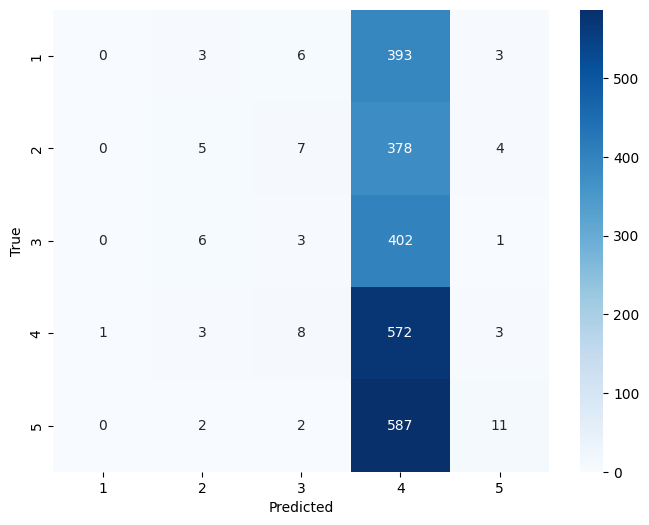

Classification Report
              precision    recall  f1-score   support

    Rating 1       0.00      0.00      0.00       405
    Rating 2       0.26      0.01      0.02       394
    Rating 3       0.12      0.01      0.01       412
    Rating 4       0.25      0.97      0.39       587
    Rating 5       0.50      0.02      0.04       602

    accuracy                           0.25      2400
   macro avg       0.22      0.20      0.09      2400
weighted avg       0.25      0.25      0.11      2400



In [12]:
def plot_history(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title(f'{title} - Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title(f'{title} - Loss')
    plt.show()

plot_history(history_rnn, "Simple RNN")
plot_history(history_lstm, "LSTM")
plot_history(history_w2v, "LSTM + Word2Vec")

print("Evaluating LSTM + Word2Vec Model:")
y_pred_probs = model_w2v.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

print('Confusion Matrix')
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=[1,2,3,4,5], yticklabels=[1,2,3,4,5], cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

print('Classification Report')
print(classification_report(y_true, y_pred, target_names=['Rating 1', 'Rating 2', 'Rating 3', 'Rating 4', 'Rating 5']))
